In [42]:
import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/zygmunt/goodbooks-10k/book_tags.csv
/kaggle/input/datasets/zygmunt/goodbooks-10k/ratings.csv
/kaggle/input/datasets/zygmunt/goodbooks-10k/books.csv
/kaggle/input/datasets/zygmunt/goodbooks-10k/sample_book.xml
/kaggle/input/datasets/zygmunt/goodbooks-10k/to_read.csv
/kaggle/input/datasets/zygmunt/goodbooks-10k/tags.csv


In [43]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split

In [44]:
DATA_PATH = "/kaggle/input/datasets/zygmunt/goodbooks-10k/"

ratings = pd.read_csv(DATA_PATH + "ratings.csv")
books   = pd.read_csv(DATA_PATH + "books.csv")

print("Ratings shape:", ratings.shape)
print("Books shape:",   books.shape)

display(ratings.head())
display(books.head())

Ratings shape: (981756, 3)
Books shape: (10000, 23)


,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [45]:
print("Ratings columns:", ratings.columns.tolist())
print("Books columns:",   books.columns.tolist())

print("\nMissing in ratings:")
print(ratings.isnull().sum())

print("\nMissing in books (top 10):")
print(books.isnull().sum().sort_values(ascending=False).head(10))

Ratings columns: ['book_id', 'user_id', 'rating']
Books columns: ['id', 'book_id', 'best_book_id', 'work_id', 'books_count', 'isbn', 'isbn13', 'authors', 'original_publication_year', 'original_title', 'title', 'language_code', 'average_rating', 'ratings_count', 'work_ratings_count', 'work_text_reviews_count', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'image_url', 'small_image_url']

Missing in ratings:
book_id    0
user_id    0
rating     0
dtype: int64

Missing in books (top 10):
language_code                1084
isbn                          700
isbn13                        585
original_title                585
original_publication_year      21
best_book_id                    0
id                              0
work_id                         0
books_count                     0
book_id                         0
dtype: int64


In [46]:
ratings = ratings[['user_id', 'book_id', 'rating']].copy()
books   = books[['book_id', 'title', 'authors', 'average_rating', 'ratings_count']].copy()

display(ratings.head())
display(books.head())

,user_id,book_id,rating
0,314,1,5
1,439,1,3
2,588,1,5
3,1169,1,4
4,1185,1,4


,book_id,title,authors,average_rating,ratings_count
0,2767052,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.34,4780653
1,3,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",4.44,4602479
2,41865,"Twilight (Twilight, #1)",Stephenie Meyer,3.57,3866839
3,2657,To Kill a Mockingbird,Harper Lee,4.25,3198671
4,4671,The Great Gatsby,F. Scott Fitzgerald,3.89,2683664


In [47]:
ratings = ratings.dropna(subset=['user_id', 'book_id', 'rating'])
books   = books.dropna(subset=['book_id', 'title'])

ratings[['user_id', 'book_id']] = ratings[['user_id', 'book_id']].astype(int)
ratings['rating'] = ratings['rating'].astype(float)
books['book_id']  = books['book_id'].astype(int)

print("Ratings after cleaning:", ratings.shape)
print("Books after cleaning:",   books.shape)

Ratings after cleaning: (981756, 3)
Books after cleaning: (10000, 5)


In [48]:
dup = ratings.duplicated(subset=['user_id', 'book_id']).sum()
print("Duplicate user-book pairs:", dup)

ratings = ratings.drop_duplicates(subset=['user_id', 'book_id'], keep='first')
print("Ratings after dedup:", ratings.shape)

Duplicate user-book pairs: 2278
Ratings after dedup: (979478, 3)


In [49]:
n_users   = ratings['user_id'].nunique()
n_books   = ratings['book_id'].nunique()
n_ratings = len(ratings)
sparsity  = 1 - n_ratings / (n_users * n_books)

print(f"Users:    {n_users}")
print(f"Books:    {n_books}")
print(f"Ratings:  {n_ratings}")
print(f"Sparsity: {sparsity*100:.4f}%")

print("\nRating distribution:")
display(ratings['rating'].value_counts().sort_index())

Users:    53424
Books:    10000
Ratings:  979478
Sparsity: 99.8167%

Rating distribution:


rating
1.0     19530
2.0     63116
3.0    248144
4.0    356620
5.0    292068
Name: count, dtype: int64

In [50]:
# Paper Eq. 4: threshold = min(R) + (max(R) - min(R)) / 2
# Keep ratings STRICTLY ABOVE the midpoint (>3.0 on a 1-5 scale, i.e. rating >= 4)
threshold = ratings['rating'].min() + (ratings['rating'].max() - ratings['rating'].min()) / 2
print(f"Rating threshold (midpoint): {threshold}")

positive_ratings = ratings[ratings['rating'] > threshold].copy()
positive_ratings['interaction'] = 1

print("Positive interactions:", positive_ratings.shape)
display(positive_ratings.head())

Rating threshold (midpoint): 3.0
Positive interactions: (648688, 4)


,user_id,book_id,rating,interaction
0,314,1,5.0,1
2,588,1,5.0,1
3,1169,1,4.0,1
4,1185,1,4.0,1
5,2077,1,4.0,1


In [51]:
MIN_USER_INTERACTIONS = 5
MIN_BOOK_INTERACTIONS = 10

while True:
    before = positive_ratings.shape[0]

    user_counts = positive_ratings['user_id'].value_counts()
    positive_ratings = positive_ratings[
        positive_ratings['user_id'].isin(user_counts[user_counts >= MIN_USER_INTERACTIONS].index)
    ]

    book_counts = positive_ratings['book_id'].value_counts()
    positive_ratings = positive_ratings[
        positive_ratings['book_id'].isin(book_counts[book_counts >= MIN_BOOK_INTERACTIONS].index)
    ]

    if positive_ratings.shape[0] == before:
        break

print("Filtered interactions:", positive_ratings.shape)
print("Users:", positive_ratings['user_id'].nunique())
print("Books:", positive_ratings['book_id'].nunique())

Filtered interactions: (595841, 4)
Users: 28930
Books: 9969


In [52]:
unique_users = positive_ratings['user_id'].unique()
unique_books = positive_ratings['book_id'].unique()

user_to_idx = {uid: i for i, uid in enumerate(unique_users)}
book_to_idx = {bid: i for i, bid in enumerate(unique_books)}
idx_to_user = {i: uid for uid, i in user_to_idx.items()}
idx_to_book = {i: bid for bid, i in book_to_idx.items()}

positive_ratings['user_idx'] = positive_ratings['user_id'].map(user_to_idx)
positive_ratings['book_idx'] = positive_ratings['book_id'].map(book_to_idx)

display(positive_ratings.head())

,user_id,book_id,rating,interaction,user_idx,book_idx
0,314,1,5.0,1,0,0
2,588,1,5.0,1,1,0
3,1169,1,4.0,1,2,0
4,1185,1,4.0,1,3,0
5,2077,1,4.0,1,4,0


In [53]:
train_list, test_list = [], []

for user_idx, group in positive_ratings.groupby('user_idx'):
    if len(group) < 2:
        train_list.append(group)
        continue
    tr, te = train_test_split(group, test_size=0.2, random_state=42)
    train_list.append(tr)
    test_list.append(te)

train_df = pd.concat(train_list).reset_index(drop=True)
test_df  = pd.concat(test_list).reset_index(drop=True)

print("Train:", train_df.shape, "| Test:", test_df.shape)
print("Train users:", train_df['user_idx'].nunique())
print("Test  users:", test_df['user_idx'].nunique())

Train: (465335, 6) | Test: (130506, 6)
Train users: 28930
Test  users: 28930


In [54]:
train_users = set(train_df['user_idx'].unique())
train_books = set(train_df['book_idx'].unique())

before = test_df.shape[0]
test_df = test_df[
    test_df['user_idx'].isin(train_users) &
    test_df['book_idx'].isin(train_books)
].reset_index(drop=True)

print(f"Test rows: {before} -> {test_df.shape[0]} (cold-start removed)")

Test rows: 130506 -> 130506 (cold-start removed)


In [55]:
num_users = positive_ratings['user_idx'].nunique()
num_books = positive_ratings['book_idx'].nunique()

train_matrix = csr_matrix(
    (train_df['interaction'], (train_df['user_idx'], train_df['book_idx'])),
    shape=(num_users, num_books)
)
test_matrix = csr_matrix(
    (test_df['interaction'], (test_df['user_idx'], test_df['book_idx'])),
    shape=(num_users, num_books)
)

print("Train matrix:", train_matrix.shape, "| nnz:", train_matrix.nnz)
print("Test  matrix:", test_matrix.shape,  "| nnz:", test_matrix.nnz)

Train matrix: (28930, 9969) | nnz: 465335
Test  matrix: (28930, 9969) | nnz: 130506


In [56]:
book_info = books[books['book_id'].isin(book_to_idx)].copy()
book_info['book_idx'] = book_info['book_id'].map(book_to_idx)
book_info = book_info.dropna(subset=['book_idx'])
book_info['book_idx'] = book_info['book_idx'].astype(int)

display(book_info.head())

,book_id,title,authors,average_rating,ratings_count,book_idx
1,3,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",4.44,4602479,2
3,2657,To Kill a Mockingbird,Harper Lee,4.25,3198671,2653
4,4671,The Great Gatsby,F. Scott Fitzgerald,3.89,2683664,4664
6,5907,The Hobbit,J.R.R. Tolkien,4.25,2071616,5897
7,5107,The Catcher in the Rye,J.D. Salinger,3.79,2044241,5099


In [57]:
train_df.to_csv("train_interactions.csv", index=False)
test_df.to_csv("test_interactions.csv",   index=False)
positive_ratings.to_csv("clean_positive_interactions.csv", index=False)
book_info.to_csv("book_info.csv", index=False)

print("Preprocessed files saved.")

Preprocessed files saved.


In [58]:
summary = {
    "Original ratings":       len(ratings),
    "Positive interactions":  len(positive_ratings),
    "Train interactions":     len(train_df),
    "Test interactions":      len(test_df),
    "Users":                  num_users,
    "Books":                  num_books,
    "Train matrix nnz":       train_matrix.nnz,
    "Test  matrix nnz":       test_matrix.nnz,
}
pd.DataFrame(summary.items(), columns=["Item", "Value"])

,Item,Value
0,Original ratings,979478
1,Positive interactions,595841
2,Train interactions,465335
3,Test interactions,130506
4,Users,28930
5,Books,9969
6,Train matrix nnz,465335
7,Test matrix nnz,130506


## RecVAE Model

RecVAE (Variational Autoencoder for top-N recommendations) is used as the embedding backbone.
Architecture: encoder -> (mu, log_sigma^2) -> reparameterise -> z -> decoder -> logits over items.

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [60]:
class InteractionDataset(Dataset):
    def __init__(self, sparse_matrix):
        self.matrix = sparse_matrix.astype("float32")
        self.num_users = sparse_matrix.shape[0]

    def __len__(self):
        return self.num_users

    def __getitem__(self, idx):
        row = self.matrix[idx].toarray().squeeze()
        return torch.tensor(row, dtype=torch.float32), idx

In [61]:
class RecVAE(nn.Module):
    """
    RecVAE architecture.

    Encoder:
      Linear(input_dim -> hidden_dim) -> Tanh -> Dropout
      -> Linear(hidden_dim -> hidden_dim) -> Tanh
      -> two heads: mu_layer and logvar_layer (both Linear(hidden_dim -> latent_dim))

    Decoder (Sequential indices):
      [0] Linear(latent_dim=200 -> hidden_dim=600)
      [1] Tanh
      [2] Linear(hidden_dim=600 -> input_dim=num_books)

    Item embeddings are extracted in the latent space as:
        item_emb = decoder[2].weight @ decoder[0].weight
               = (num_books, 600) @ (600, 200) = (num_books, 200)
    This places items in the same 200-dim space as the encoder mu (user embeddings).
    """
    def __init__(self, input_dim, hidden_dim=600, latent_dim=200, dropout=0.5):
        super().__init__()
        self.input_dim  = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh()
        )
        self.mu_layer     = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)

        # decoder[0]=Linear(latent->hidden), decoder[1]=Tanh, decoder[2]=Linear(hidden->items)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            return mu + torch.randn_like(std) * std
        return mu

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        x_norm     = F.normalize(x, dim=1)
        mu, logvar = self.encode(x_norm)
        z          = self.reparameterize(mu, logvar)
        logits     = self.decode(z)
        return logits, mu, logvar

In [62]:
def recvae_loss(logits, x, mu, logvar, beta=0.2):
    """
    Multinomial log-likelihood reconstruction + beta-weighted KL divergence.
    beta=0.2 follows the paper setting.
    """
    recon = -torch.mean(torch.sum(F.log_softmax(logits, dim=1) * x, dim=1))
    kl    = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return recon + beta * kl, recon, kl

In [63]:
BATCH_SIZE = 256

train_dataset = InteractionDataset(train_matrix)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Users:", train_matrix.shape[0])
print("Books:", train_matrix.shape[1])
print("Batches per epoch:", len(train_loader))

Users: 28930
Books: 9969
Batches per epoch: 114


In [64]:
num_books_model = train_matrix.shape[1]

model = RecVAE(
    input_dim  = num_books_model,
    hidden_dim = 600,
    latent_dim = 200,
    dropout    = 0.5
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(model)

RecVAE(
  (encoder): Sequential(
    (0): Linear(in_features=9969, out_features=600, bias=True)
    (1): Tanh()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=600, out_features=600, bias=True)
    (4): Tanh()
  )
  (mu_layer): Linear(in_features=600, out_features=200, bias=True)
  (logvar_layer): Linear(in_features=600, out_features=200, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=200, out_features=600, bias=True)
    (1): Tanh()
    (2): Linear(in_features=600, out_features=9969, bias=True)
  )
)


In [65]:
EPOCHS = 50
BETA   = 0.2

training_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    tot_loss = tot_recon = tot_kl = 0.0

    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()
        logits, mu, logvar = model(batch_x)
        loss, recon, kl    = recvae_loss(logits, batch_x, mu, logvar, beta=BETA)
        loss.backward()
        optimizer.step()
        tot_loss  += loss.item()
        tot_recon += recon.item()
        tot_kl    += kl.item()

    n = len(train_loader)
    training_history.append({
        "epoch":               epoch,
        "loss":               tot_loss  / n,
        "reconstruction_loss": tot_recon / n,
        "kl_loss":            tot_kl    / n,
    })
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Loss: {tot_loss/n:.4f} | "
          f"Recon: {tot_recon/n:.4f} | "
          f"KL: {tot_kl/n:.4f}")

Epoch 01/50 | Loss: 142.0018 | Recon: 140.7537 | KL: 6.2403
Epoch 02/50 | Loss: 126.4603 | Recon: 122.8939 | KL: 17.8319
Epoch 03/50 | Loss: 121.0771 | Recon: 116.6268 | KL: 22.2518
Epoch 04/50 | Loss: 118.6211 | Recon: 113.5645 | KL: 25.2828
Epoch 05/50 | Loss: 116.8402 | Recon: 111.3511 | KL: 27.4452
Epoch 06/50 | Loss: 114.5203 | Recon: 108.7451 | KL: 28.8764
Epoch 07/50 | Loss: 112.3419 | Recon: 106.3269 | KL: 30.0747
Epoch 08/50 | Loss: 110.7116 | Recon: 104.5655 | KL: 30.7304
Epoch 09/50 | Loss: 109.8502 | Recon: 103.5309 | KL: 31.5967
Epoch 10/50 | Loss: 107.9850 | Recon: 101.6598 | KL: 31.6260
Epoch 11/50 | Loss: 106.2728 | Recon: 99.8467 | KL: 32.1301
Epoch 12/50 | Loss: 105.1622 | Recon: 98.7392 | KL: 32.1146
Epoch 13/50 | Loss: 104.6859 | Recon: 98.1450 | KL: 32.7045
Epoch 14/50 | Loss: 103.6140 | Recon: 97.0100 | KL: 33.0198
Epoch 15/50 | Loss: 102.1062 | Recon: 95.4454 | KL: 33.3039
Epoch 16/50 | Loss: 101.7356 | Recon: 94.9728 | KL: 33.8137
Epoch 17/50 | Loss: 100.9218 | 

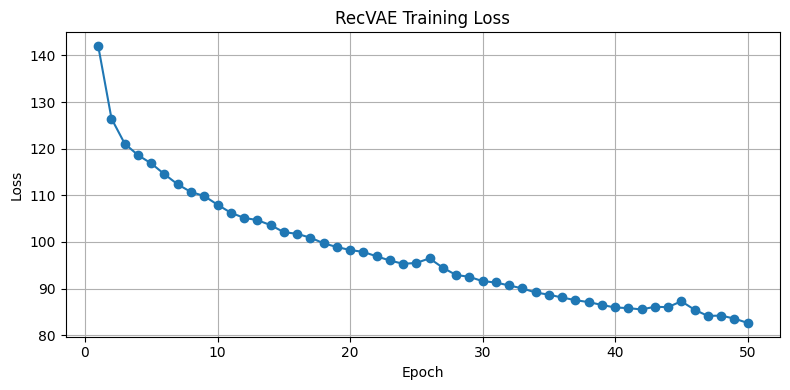

In [66]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(training_history)

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["loss"], marker="o")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("RecVAE Training Loss")
plt.grid(True); plt.tight_layout(); plt.show()

## Extract Embeddings (Paper-Correct Method)

The paper uses shared embeddings for both user-item and item-item recommendations:

**User embeddings p_u** = encoder mean mu for each user's training interaction vector
  - Extracted by passing the training vector through the encoder and taking mu
  - Shape: (num_users, latent_dim=200)

**Item embeddings q_i** = items projected into the same latent space
  - Correct formula: `decoder[2].weight @ decoder[0].weight`
  - decoder[0].weight shape: (hidden_dim=600, latent_dim=200)
  - decoder[2].weight shape: (num_books, hidden_dim=600)
  - Product: (num_books, 600) @ (600, 200) = (num_books, 200) -- same space as user mu
  - Shape: (num_books, latent_dim=200)

Both are L2-normalised so all dot products equal cosine similarities in [-1, 1].

In [67]:
model.eval()

# ── 1. User embeddings: encoder mu, shape (num_users, latent_dim=200) ─────────
all_mu = []
with torch.no_grad():
    for batch_x, _ in DataLoader(train_dataset, batch_size=256, shuffle=False):
        batch_x = batch_x.to(device)
        mu, _   = model.encode(F.normalize(batch_x, dim=1))
        all_mu.append(mu.cpu().numpy())
user_embeddings = np.vstack(all_mu)                    # (num_users, 200)

# ── 2. Item embeddings in latent space (num_books, 200) ──────────────────────
# decoder[0].weight shape: (hidden_dim=600, latent_dim=200)
# decoder[2].weight shape: (num_books,      hidden_dim=600)
# W2 @ W1 = (num_books, 600) @ (600, 200) = (num_books, 200)  <-- correct!
# This is the only way to get items and users in the same 200-dim latent space.
W1 = model.decoder[0].weight.detach().cpu().numpy()    # (600, 200)
W2 = model.decoder[2].weight.detach().cpu().numpy()    # (num_books, 600)
item_embeddings = W2 @ W1                              # (num_books, 200)

print("user_embeddings shape:", user_embeddings.shape)  # (num_users, 200)
print("item_embeddings shape:", item_embeddings.shape)  # (num_books, 200)
assert user_embeddings.shape[1] == item_embeddings.shape[1], \
    f"Latent dim mismatch: {user_embeddings.shape[1]} vs {item_embeddings.shape[1]}"

# ── 3. L2-normalise both so dot-product == cosine similarity ──────────────────
def l2_normalize(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return matrix / norms

user_emb_norm = l2_normalize(user_embeddings)          # (num_users, 200)
item_emb_norm = l2_normalize(item_embeddings)          # (num_books, 200)

print("user_emb_norm shape:", user_emb_norm.shape)
print("item_emb_norm shape:", item_emb_norm.shape)

user_embeddings shape: (28930, 200)
item_embeddings shape: (9969, 200)
user_emb_norm shape: (28930, 200)
item_emb_norm shape: (9969, 200)


## Step 1 - User-Item Similarity R_u,i  (Equation 1)

R_u,i = p_u . q_i   (cosine similarity after L2 normalisation)

Seen items are masked to -inf so they never appear in the top-K list.

In [68]:
# Cosine similarity: every user vs every book  (num_users, num_books)
ui_scores = user_emb_norm @ item_emb_norm.T
print("R (User-Item scores) shape:", ui_scores.shape)
print("Value range: [{:.4f}, {:.4f}]".format(ui_scores.min(), ui_scores.max()))

# Mask training (seen) items -- they must not appear in recommendations
train_rows, train_cols = train_matrix.nonzero()
ui_scores_filtered = ui_scores.copy()
ui_scores_filtered[train_rows, train_cols] = -np.inf

print("Seen books masked in R.")

R (User-Item scores) shape: (28930, 9969)
Value range: [-0.8848, 0.9482]
Seen books masked in R.


## Step 2 - Item-Item Similarity S_u,i  (Equation 2)

S_u,i = (1 / |I_u|) * sum_{j in I_u}  q_i . q_j

Vectorised: S = (train_matrix @ item_similarity_matrix) / history_lengths

This averages the cosine similarity between candidate item i and every book the user has consumed.

In [69]:
# Full item x item cosine similarity matrix -- already L2-normalised, so dot = cosine
item_similarity = item_emb_norm @ item_emb_norm.T       # (num_books, num_books)
print("Item-Item similarity shape:", item_similarity.shape)
print("Value range: [{:.4f}, {:.4f}]".format(item_similarity.min(), item_similarity.max()))

# Vectorised Eq. 2
train_matrix_float = train_matrix.astype("float32")
ii_scores          = np.array(train_matrix_float @ item_similarity)  # (num_users, num_books)

history_lengths = np.array(train_matrix_float.sum(axis=1)).flatten()
history_lengths[history_lengths == 0] = 1.0               # avoid division by zero

ii_scores = ii_scores / history_lengths[:, None]           # normalise by |I_u|
print("S (Item-Item scores) shape:", ii_scores.shape)
print("Value range: [{:.4f}, {:.4f}]".format(ii_scores.min(), ii_scores.max()))

# Mask training (seen) items
ii_scores_filtered = ii_scores.copy()
ii_scores_filtered[train_rows, train_cols] = -np.inf
print("Seen books masked in S.")

Item-Item similarity shape: (9969, 9969)
Value range: [-0.9131, 1.0000]
S (Item-Item scores) shape: (28930, 9969)
Value range: [-0.8620, 0.9804]
Seen books masked in S.


## Step 3 - Weighted Similarity Z_u,i  (Equation 3)

Z_u,i = (w_R * R_u,i + w_S * S_u,i) / (w_R + w_S)

Both R and S are cosine similarities so the weighted average is scale-consistent.
The paper tests five weight ratios: {1:4, 2:3, 1:1, 3:2, 4:1}.

In [70]:
def compute_weighted_scores(R, S, w_r, w_s):
    """Paper Eq. 3: weighted combination of user-item and item-item scores."""
    return (w_r * R + w_s * S) / (w_r + w_s)

weight_ratios = {
    "WS_1_4": (1, 4),   # item-item dominant
    "WS_2_3": (2, 3),
    "WS_1_1": (1, 1),   # equal weight
    "WS_3_2": (3, 2),
    "WS_4_1": (4, 1),   # user-item dominant
}

weighted_scores_dict = {}
for name, (w_r, w_s) in weight_ratios.items():
    weighted_scores_dict[name] = compute_weighted_scores(
        ui_scores_filtered, ii_scores_filtered, w_r, w_s
    )
    print(f"{name}: w_R={w_r}, w_S={w_s}")

WS_1_4: w_R=1, w_S=4
WS_2_3: w_R=2, w_S=3
WS_1_1: w_R=1, w_S=1
WS_3_2: w_R=3, w_S=2
WS_4_1: w_R=4, w_S=1


## Personalised Weight Enhancement (Novel Contribution)

Instead of a single global weight ratio, each user receives weights derived from
their own interaction history length.

**Rationale:** users with a rich history provide more reliable item-item signal,
so the item-item component should be weighted higher for them.

    w_S(u) = clip(|I_u| / 10,  min=1,  max=4)   <- grows with history, capped at 4
    w_R(u) = 5 - w_S(u)                          <- always sums to 5

- Sparse users  (|I_u| <= 10): w_R=4, w_S=1  -> lean on the user profile
- Active users  (|I_u| >= 40): w_R=1, w_S=4  -> lean on item neighbourhood

**Implementation note:** -inf sentinel values in the masked score arrays must be
handled before arithmetic (replaced with -1e9), then the mask is re-applied after
weighting to keep seen items suppressed.

In [71]:
# Per-user history length from the training matrix
history_lengths_clipped = np.array(train_matrix.sum(axis=1)).flatten()   # (num_users,)

# Weights: w_S grows with history length, w_R compensates; w_R + w_S = 5 always
w_s_personalized = np.clip(history_lengths_clipped / 10, 1, 4)           # in [1, 4]
w_r_personalized = 5 - w_s_personalized                                   # in [1, 4]

# Replace -inf with a large negative finite number before weighted arithmetic.
# Direct arithmetic on -inf produces NaN (e.g. -inf * 0, inf - inf).
R_safe = np.where(np.isinf(ui_scores_filtered), -1e9, ui_scores_filtered)
S_safe = np.where(np.isinf(ii_scores_filtered), -1e9, ii_scores_filtered)

personalized_ws_scores = (
    w_r_personalized[:, None] * R_safe +
    w_s_personalized[:, None] * S_safe
) / (w_r_personalized[:, None] + w_s_personalized[:, None])

# Re-apply mask: any position seen in either R or S stays suppressed
seen_mask = np.isinf(ui_scores_filtered) | np.isinf(ii_scores_filtered)
personalized_ws_scores[seen_mask] = -np.inf

print("Personalized WS shape:", personalized_ws_scores.shape)
print(f"w_R range: [{w_r_personalized.min():.2f}, {w_r_personalized.max():.2f}]")
print(f"w_S range: [{w_s_personalized.min():.2f}, {w_s_personalized.max():.2f}]")

Personalized WS shape: (28930, 9969)
w_R range: [1.00, 4.00]
w_S range: [1.00, 4.00]


## Quick Sanity Check - Sample Recommendations

In [72]:
def get_top_n(scores_matrix, user_idx, n=10):
    scores    = scores_matrix[user_idx]
    top_items = np.argpartition(-scores, n)[:n]
    return top_items[np.argsort(-scores[top_items])]

sample_user   = 0
top_books_idx = get_top_n(ui_scores_filtered, sample_user, n=10)
rec_book_ids  = [idx_to_book[i] for i in top_books_idx]

display(
    books[books["book_id"].isin(rec_book_ids)][
        ["book_id", "title", "authors", "average_rating"]
    ]
)

,book_id,title,authors,average_rating
26,1,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré",4.54
373,21,A Short History of Nearly Everything,Bill Bryson,4.19
7682,98,What to Expect the First Year (What to Expect),"Heidi Murkoff, Sharon Mazel, Heidi Murkoff, Ar...",3.86


## Evaluation - HR@K and NDCG@K

Metrics follow the paper (Equations 5-8).

- **HR@K** = fraction of users with at least one test item in the top-K list
- **NDCG@K** = normalised discounted cumulative gain (rewards hits ranked higher)

In [73]:
def get_user_test_items(test_matrix):
    """Dict: user_idx -> set of held-out item indices."""
    user_test_items = {}
    csr = test_matrix.tocsr()
    for u in range(csr.shape[0]):
        items = csr[u].indices
        if len(items) > 0:
            user_test_items[u] = set(items)
    return user_test_items


def get_top_k_items(scores, k):
    """Indices of the top-k unseen items for one user (descending score order)."""
    top = np.argpartition(-scores, k)[:k]
    return top[np.argsort(-scores[top])]


def hit_rate_at_k(scores_matrix, user_test_items, k=10):
    """HR@k -- fraction of users with at least one hit in top-k."""
    hits, total = 0, 0
    for u, true_items in user_test_items.items():
        top_k = get_top_k_items(scores_matrix[u], k)
        if set(top_k) & true_items:
            hits += 1
        total += 1
    return hits / total


def ndcg_at_k(scores_matrix, user_test_items, k=10):
    """NDCG@k -- average normalised discounted cumulative gain."""
    total, count = 0.0, 0
    for u, true_items in user_test_items.items():
        top_k = get_top_k_items(scores_matrix[u], k)
        dcg   = sum(
            1 / np.log2(rank + 2)
            for rank, item in enumerate(top_k)
            if item in true_items
        )
        ideal_hits = min(len(true_items), k)
        idcg = sum(1 / np.log2(r + 2) for r in range(ideal_hits))
        if idcg > 0:
            total += dcg / idcg
            count += 1
    return total / count if count > 0 else 0.0


# Build ground-truth dict once
user_test_items = get_user_test_items(test_matrix)
print("Users with test items:", len(user_test_items))

Users with test items: 28930


In [74]:
models_to_evaluate = {
    "RecVAE-UI":              ui_scores_filtered,
    "RecVAE-II":              ii_scores_filtered,
    "RecVAE-Personalized-WS": personalized_ws_scores,
}
for ws_name, ws_scores in weighted_scores_dict.items():
    models_to_evaluate[f"RecVAE-{ws_name}"] = ws_scores

print("Models to evaluate:", list(models_to_evaluate.keys()))

Ks = [5, 10, 20]
results = []

for K in Ks:
    for model_name, scores_matrix in models_to_evaluate.items():
        hr   = hit_rate_at_k(scores_matrix, user_test_items, k=K)
        ndcg = ndcg_at_k(scores_matrix, user_test_items, k=K)
        results.append({"Model": model_name, "K": K, "HR": hr, "NDCG": ndcg})
        print(f"K={K:2d} | {model_name:<30} | HR={hr:.4f} | NDCG={ndcg:.4f}")

results_df = pd.DataFrame(results)
display(results_df)

Models to evaluate: ['RecVAE-UI', 'RecVAE-II', 'RecVAE-Personalized-WS', 'RecVAE-WS_1_4', 'RecVAE-WS_2_3', 'RecVAE-WS_1_1', 'RecVAE-WS_3_2', 'RecVAE-WS_4_1']
K= 5 | RecVAE-UI                      | HR=0.2716 | NDCG=0.1057
K= 5 | RecVAE-II                      | HR=0.2626 | NDCG=0.1067
K= 5 | RecVAE-Personalized-WS         | HR=0.2807 | NDCG=0.1115
K= 5 | RecVAE-WS_1_4                  | HR=0.2848 | NDCG=0.1151
K= 5 | RecVAE-WS_2_3                  | HR=0.2929 | NDCG=0.1181
K= 5 | RecVAE-WS_1_1                  | HR=0.2922 | NDCG=0.1177
K= 5 | RecVAE-WS_3_2                  | HR=0.2901 | NDCG=0.1166
K= 5 | RecVAE-WS_4_1                  | HR=0.2842 | NDCG=0.1123
K=10 | RecVAE-UI                      | HR=0.3634 | NDCG=0.1180
K=10 | RecVAE-II                      | HR=0.3583 | NDCG=0.1200
K=10 | RecVAE-Personalized-WS         | HR=0.3760 | NDCG=0.1247
K=10 | RecVAE-WS_1_4                  | HR=0.3810 | NDCG=0.1285
K=10 | RecVAE-WS_2_3                  | HR=0.3878 | NDCG=0.1316
K=10 | Rec

,Model,K,HR,NDCG
0,RecVAE-UI,5,0.271587,0.105705
1,RecVAE-II,5,0.262565,0.106724
2,RecVAE-Personalized-WS,5,0.280747,0.111495
3,RecVAE-WS_1_4,5,0.284791,0.115058
4,RecVAE-WS_2_3,5,0.292948,0.118085
5,RecVAE-WS_1_1,5,0.292188,0.117660
6,RecVAE-WS_3_2,5,0.290114,0.116586
7,RecVAE-WS_4_1,5,0.284238,0.112265
8,RecVAE-UI,10,0.363394,0.117976
9,RecVAE-II,10,0.358279,0.119968


In [75]:
results_df.to_csv("evaluation_results.csv", index=False)
print("Saved evaluation_results.csv")

Saved evaluation_results.csv


In [76]:
print("=== Best model by NDCG at each K ===")
for K_val in sorted(results_df["K"].unique()):
    sub  = results_df[results_df["K"] == K_val]
    best = sub.sort_values("NDCG", ascending=False).iloc[0]
    print(f"  K={K_val:2d} -> {best['Model']:<30}  NDCG={best['NDCG']:.4f}  HR={best['HR']:.4f}")

=== Best model by NDCG at each K ===
  K= 5 -> RecVAE-WS_2_3                   NDCG=0.1181  HR=0.2929
  K=10 -> RecVAE-WS_2_3                   NDCG=0.1316  HR=0.3878
  K=20 -> RecVAE-WS_2_3                   NDCG=0.1510  HR=0.4899


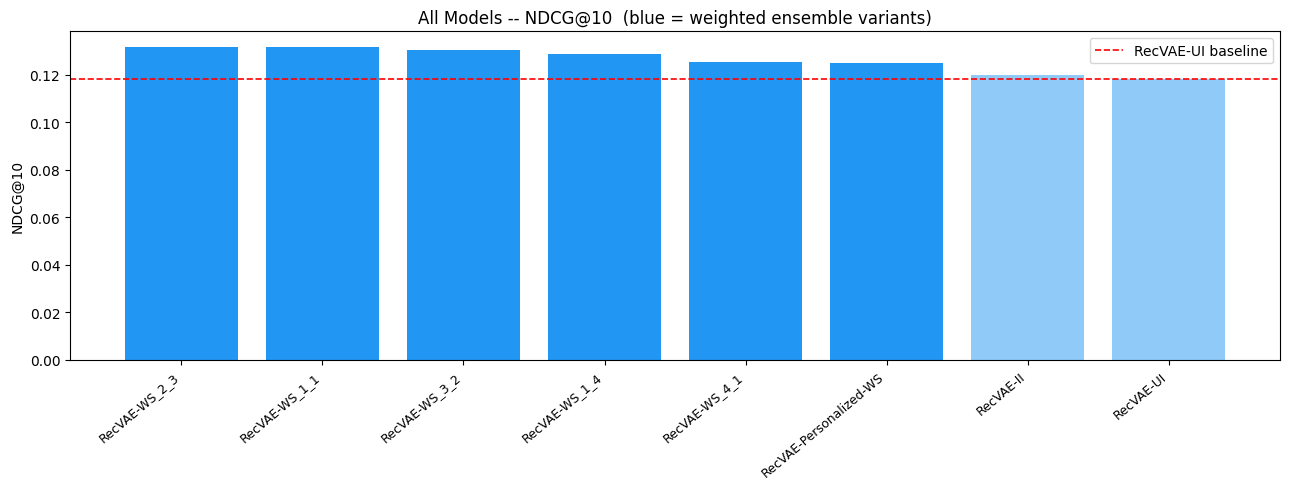

In [77]:
import matplotlib.pyplot as plt

K_plot = 10
sub    = results_df[results_df["K"] == K_plot].sort_values("NDCG", ascending=False)

plt.figure(figsize=(13, 5))
colors = ["#2196F3" if "WS" in m else "#90CAF9" for m in sub["Model"]]
plt.bar(sub["Model"], sub["NDCG"], color=colors)
plt.axhline(
    sub[sub["Model"] == "RecVAE-UI"]["NDCG"].values[0],
    color="red", linestyle="--", linewidth=1.2, label="RecVAE-UI baseline"
)
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.ylabel(f"NDCG@{K_plot}")
plt.title(f"All Models -- NDCG@{K_plot}  (blue = weighted ensemble variants)")
plt.legend(); plt.tight_layout(); plt.show()

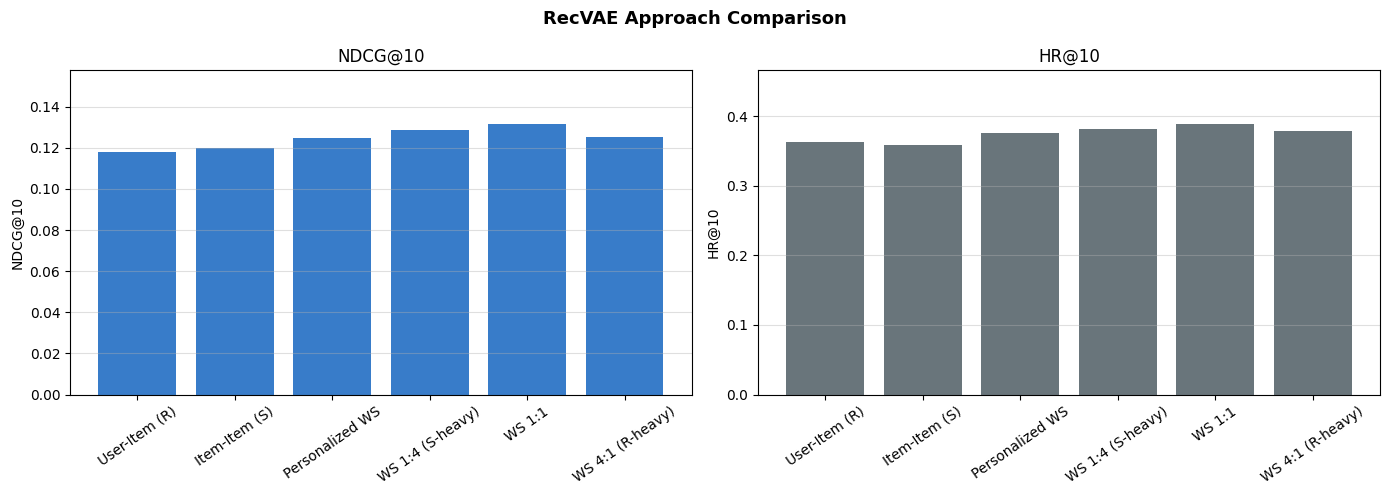

In [78]:
K_plot = 10
sub    = results_df[results_df["K"] == K_plot].copy()

approach_map = {
    "RecVAE-UI":              "User-Item (R)",
    "RecVAE-II":              "Item-Item (S)",
    "RecVAE-WS_1_1":          "WS 1:1",
    "RecVAE-WS_1_4":          "WS 1:4 (S-heavy)",
    "RecVAE-WS_4_1":          "WS 4:1 (R-heavy)",
    "RecVAE-Personalized-WS": "Personalized WS",
}
plot_df          = sub[sub["Model"].isin(approach_map)].copy()
plot_df["Label"] = plot_df["Model"].map(approach_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(plot_df["Label"], plot_df["NDCG"], color="#1565C0", alpha=0.85)
axes[0].set_title(f"NDCG@{K_plot}"); axes[0].set_ylabel(f"NDCG@{K_plot}")
axes[0].set_ylim(0, plot_df["NDCG"].max() * 1.2)
axes[0].tick_params(axis="x", rotation=35); axes[0].grid(axis="y", alpha=0.4)

axes[1].bar(plot_df["Label"], plot_df["HR"], color="#37474F", alpha=0.75)
axes[1].set_title(f"HR@{K_plot}"); axes[1].set_ylabel(f"HR@{K_plot}")
axes[1].set_ylim(0, plot_df["HR"].max() * 1.2)
axes[1].tick_params(axis="x", rotation=35); axes[1].grid(axis="y", alpha=0.4)

plt.suptitle("RecVAE Approach Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

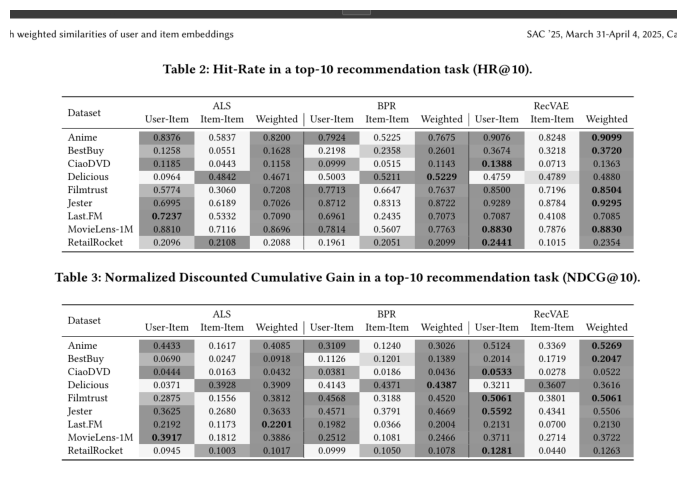

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("/kaggle/input/datasets/naghamalshbrawi/reultes-the-paper/2026-05-17 020735.png")
plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis('off') 
plt.show()

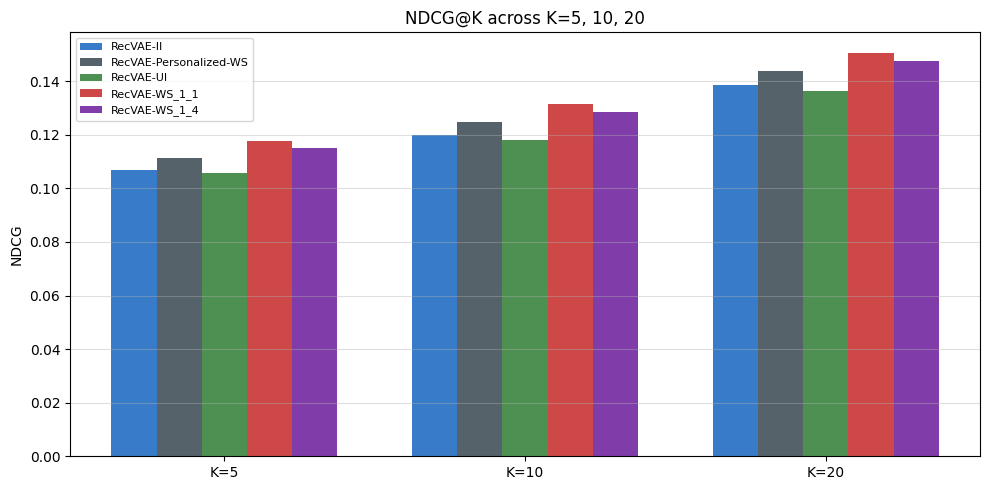

In [79]:
main_models = ["RecVAE-UI", "RecVAE-II", "RecVAE-WS_1_1",
               "RecVAE-WS_1_4", "RecVAE-Personalized-WS"]

pivot = results_df[results_df["Model"].isin(main_models)].pivot(
    index="Model", columns="K", values="NDCG"
)

x      = np.arange(len(pivot.columns))
width  = 0.15
colors = ["#1565C0", "#37474F", "#2E7D32", "#C62828", "#6A1B9A"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (mdl, row) in enumerate(pivot.iterrows()):
    ax.bar(x + i * width, row.values, width, label=mdl, color=colors[i], alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels([f"K={k}" for k in pivot.columns])
ax.set_ylabel("NDCG")
ax.set_title("NDCG@K across K=5, 10, 20")
ax.legend(fontsize=8, loc="upper left")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

In [80]:
def show_user_recommendations(scores_matrix, user_idx, k=10):
    """Show top-k recommendations for one user with hit indicators."""
    top_k      = get_top_k_items(scores_matrix[user_idx], k)
    true_items = user_test_items.get(user_idx, set())

    rows = []
    for rank, item_idx in enumerate(top_k, start=1):
        book_id  = idx_to_book[item_idx]
        book_row = books[books["book_id"] == book_id]
        if book_row.empty:
            continue
        book_row = book_row.iloc[0]
        rows.append({
            "Rank":    rank,
            "Book ID": book_id,
            "Title":   book_row["title"],
            "Authors": book_row["authors"],
            "Hit":     "YES" if item_idx in true_items else ""
        })
    return pd.DataFrame(rows)

example_user = list(user_test_items.keys())[0]
print(f"Top-10 recommendations for user index {example_user}")
print(f"(Hit=YES means the book appears in the held-out test set)\n")
display(show_user_recommendations(personalized_ws_scores, example_user, k=10))

Top-10 recommendations for user index 0
(Hit=YES means the book appears in the held-out test set)



,Rank,Book ID,Title,Authors,Hit
0,1,98,What to Expect the First Year (What to Expect),"Heidi Murkoff, Sharon Mazel, Heidi Murkoff, Ar...",


## Personalised Weight Analysis

Visualise how the per-user weights shift with history length.

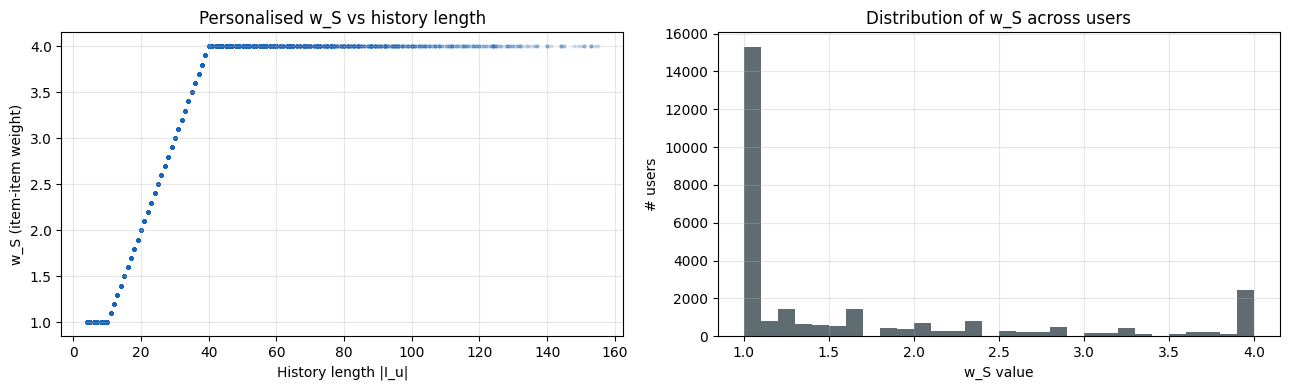

Users at min w_S=1 (sparse): 15,297
Users at max w_S=4 (active): 2,444


In [81]:
hist_len_all = np.array(train_matrix.sum(axis=1)).flatten()

w_s_vals = np.clip(hist_len_all / 10, 1, 4)
w_r_vals = 5 - w_s_vals

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(hist_len_all, w_s_vals, alpha=0.15, s=4, color="#1565C0")
axes[0].set_xlabel("History length |I_u|")
axes[0].set_ylabel("w_S (item-item weight)")
axes[0].set_title("Personalised w_S vs history length")
axes[0].grid(alpha=0.3)

axes[1].hist(w_s_vals, bins=30, color="#37474F", alpha=0.8)
axes[1].set_xlabel("w_S value"); axes[1].set_ylabel("# users")
axes[1].set_title("Distribution of w_S across users")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Users at min w_S=1 (sparse): {(w_s_vals == 1).sum():,}")
print(f"Users at max w_S=4 (active): {(w_s_vals == 4).sum():,}")

In [82]:
import pickle

torch.save(model.state_dict(), "recvae_model.pth")
np.save("ui_scores.npy",          ui_scores)
np.save("ui_scores_filtered.npy", ui_scores_filtered)
np.save("ii_scores.npy",          ii_scores)
np.save("ii_scores_filtered.npy", ii_scores_filtered)
np.save("user_embeddings.npy",    user_embeddings)
np.save("item_embeddings.npy",    item_embeddings)

with open("mappings.pkl", "wb") as f:
    pickle.dump({
        "user_to_idx": user_to_idx,
        "book_to_idx": book_to_idx,
        "idx_to_user": idx_to_user,
        "idx_to_book": idx_to_book,
    }, f)

print("All artefacts saved.")

All artefacts saved.
